# Phase 10 — Regime Analysis

**Strategy**: Momentum → Top-5 → 200DMA → HRP

**Central question**: Where does momentum work? Where does it fail?

**Hypothesis**: Momentum loves trending markets (bull or bear). Momentum crashes when markets reverse sharply — recent losers become winners overnight, and the strategy is still holding yesterday's trends.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from src.data import load_prices, compute_returns, load_risk_free_rate
from src.backtest import load_backtest_returns
from src.regime_analysis import (
    run_regime_analysis, REGIMES, REGIME_COLOR, REGIME_TYPE
)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


In [2]:
prices  = load_prices(directory='../data/processed')
returns = compute_returns(prices)

res = run_regime_analysis(prices, returns, proc_dir='../data/processed')

df        = res['regime_table']
roll      = res['rolling']
hrp_ret   = res['hrp_ret']
spy_ret   = res['spy_ret']
rf_monthly = res['rf_monthly']


  REGIME ANALYSIS — Momentum → Top-5 → 200DMA → HRP
  Regime                 N     HRP%      SH    MaxDD     SPY%    Alpha   ΔSharpe  Type
  ──────────────────── ───  ───────  ──────  ───────  ───────  ───────  ────────  ─────────────────────────
  Pre-GFC Bull          32    11.13   0.972    -4.89    10.87    +0.26    +0.075  Trending
  GFC Bear              18    12.45   0.814    -8.23   -35.49   +47.94    +2.687  Trending↓  (WORKS)
  GFC Reversal          10     3.92   0.266    -7.65    68.19   -64.27    -4.946  Reversal   (FAILS)
  QE Bull              120     8.44   0.813   -12.86    13.44    -5.00    -0.223  Low-vol grind
  COVID Crash            3    -5.81  -1.067    -0.11   -57.90   +52.09    +1.635  Trending↓  (WORKS)
  COVID Recovery        21    18.60   1.609    -6.23    43.92   -25.32    -1.285  Reversal   (FAILS)
  Inflation Bear        12     7.97   1.006    -0.08   -18.18   +26.15    +1.881  Trending↓  (WORKS)
  Recovery              42    17.80   1.165    -8.36    22.1

## Alpha by Regime

The single most important chart: active return (HRP CAGR − SPY CAGR) per regime.

- Blue bars = momentum wins
- Red bars = momentum fails

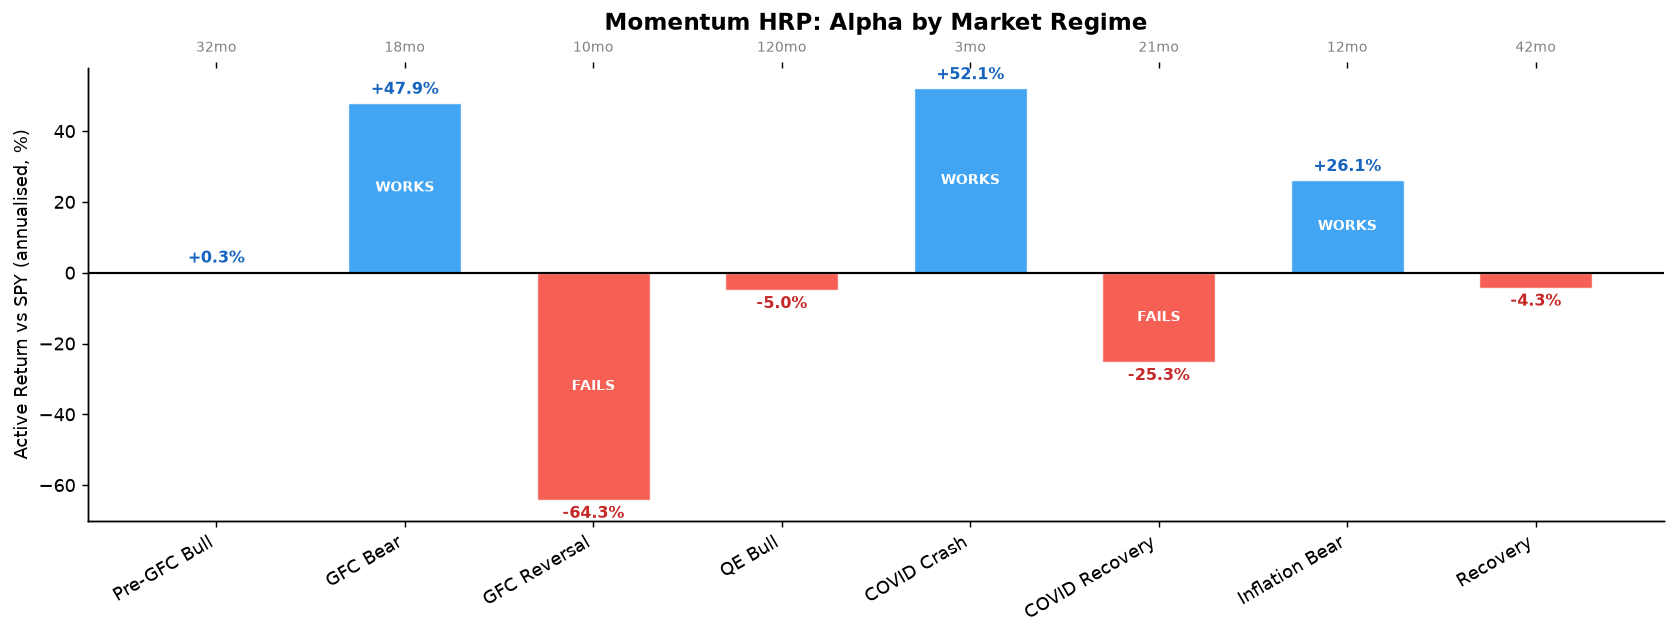


Top insight: Momentum alpha is POSITIVE in trending markets (bear OR bull).
              Momentum alpha is NEGATIVE in sharp reversals (V-shaped recoveries).


In [3]:
fig, ax = plt.subplots(figsize=(13, 5))

regimes = df.index.tolist()
alphas  = df['Alpha CAGR'].values
x       = np.arange(len(regimes))
cols    = ['#2196F3' if a > 0 else '#F44336' for a in alphas]

bars = ax.bar(x, alphas, color=cols, alpha=0.85, edgecolor='white', linewidth=0.8, width=0.6)
ax.axhline(0, color='black', linewidth=1.2)

# Value labels on bars
for i, (b, v) in enumerate(zip(bars, alphas)):
    va = 'bottom' if v >= 0 else 'top'
    offset = 1.5 if v >= 0 else -1.5
    ax.text(b.get_x() + b.get_width()/2, v + offset, f'{v:+.1f}%',
            ha='center', va=va, fontsize=9, fontweight='bold',
            color='#1565C0' if v >= 0 else '#C62828')

ax.set_xticks(x)
ax.set_xticklabels(regimes, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Active Return vs SPY (annualised, %)')
ax.set_title('Momentum HRP: Alpha by Market Regime', fontweight='bold', fontsize=13)

# Annotate type
for i, (r, v) in enumerate(zip(regimes, alphas)):
    rtype = REGIME_TYPE[r]
    if 'WORKS' in rtype or 'FAILS' in rtype:
        label = 'WORKS' if v > 0 else 'FAILS'
        ax.text(i, v/2, label, ha='center', va='center', fontsize=7.5,
                color='white', fontweight='bold')

# Add month counts as x-axis subticks
n_months = df['N months'].values
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(x)
ax2.set_xticklabels([f'{n}mo' for n in n_months], fontsize=8, color='gray')
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

print('\nTop insight: Momentum alpha is POSITIVE in trending markets (bear OR bull).')
print('              Momentum alpha is NEGATIVE in sharp reversals (V-shaped recoveries).')

## HRP vs SPY: Side-by-Side CAGR by Regime

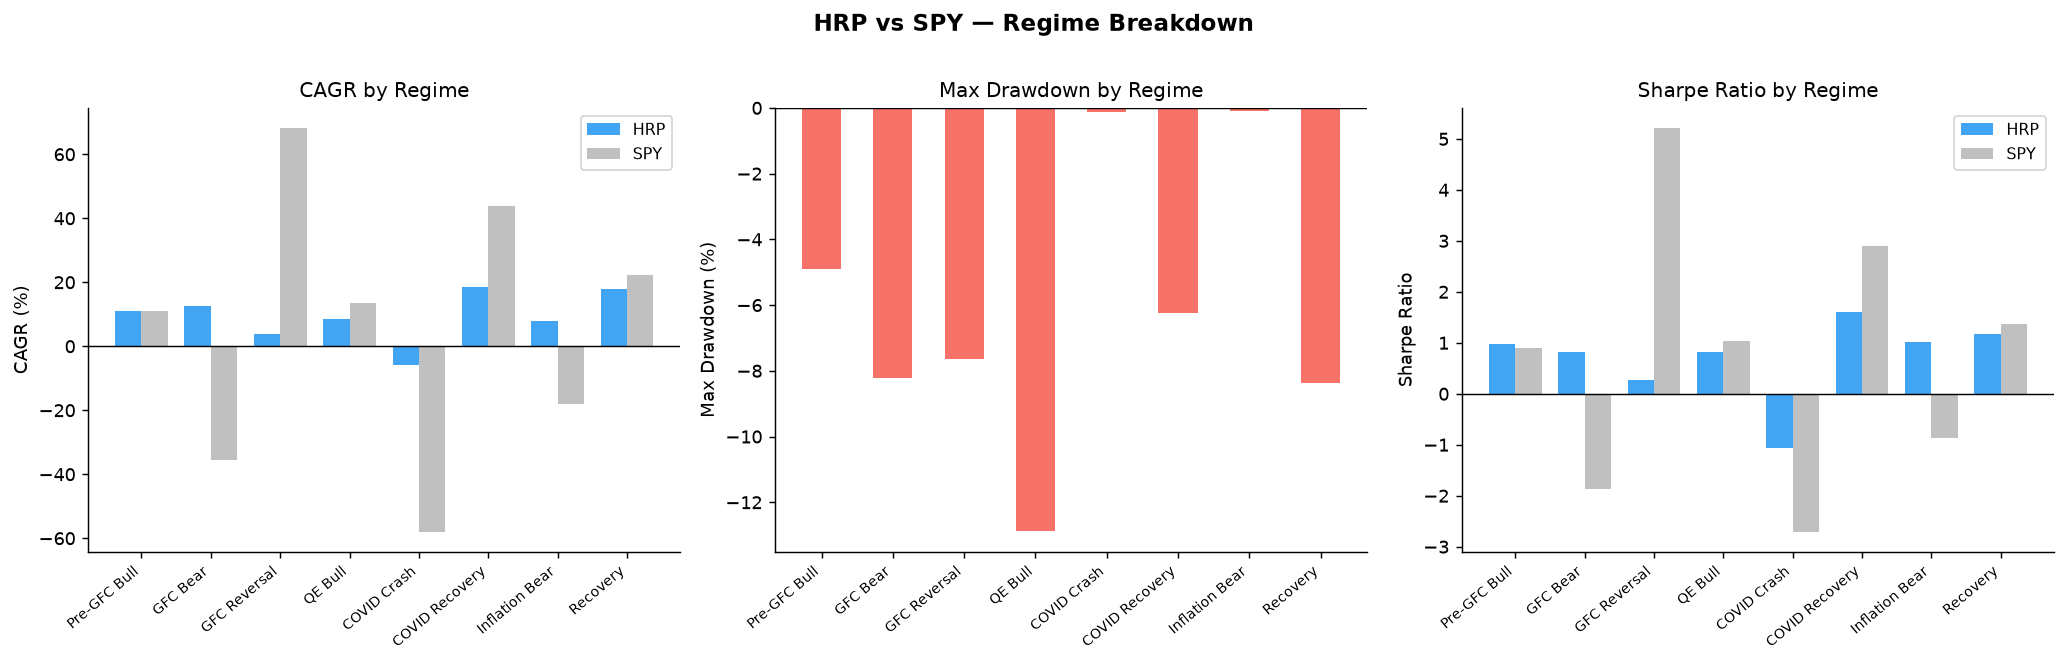

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(regimes))
w = 0.38

# CAGR comparison
ax = axes[0]
hrp_c = df['HRP CAGR %'].values
spy_c = df['SPY CAGR %'].values
ax.bar(x - w/2, hrp_c, w, label='HRP', color='#2196F3', alpha=0.85)
ax.bar(x + w/2, spy_c, w, label='SPY', color='#9E9E9E', alpha=0.65)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(regimes, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('CAGR (%)')
ax.set_title('CAGR by Regime')
ax.legend(fontsize=9)

# MaxDD comparison
ax = axes[1]
hrp_dd = df['HRP MaxDD %'].values
ax.bar(x, hrp_dd, color='#F44336', alpha=0.75, label='HRP MaxDD', width=0.55)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(regimes, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Max Drawdown (%)')
ax.set_title('Max Drawdown by Regime')

# Sharpe comparison
ax = axes[2]
hrp_sh = df['HRP Sharpe'].values
spy_sh = df['SPY Sharpe'].values
ax.bar(x - w/2, hrp_sh, w, label='HRP', color='#2196F3', alpha=0.85)
ax.bar(x + w/2, spy_sh, w, label='SPY', color='#9E9E9E', alpha=0.65)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(regimes, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio by Regime')
ax.legend(fontsize=9)

fig.suptitle('HRP vs SPY — Regime Breakdown', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Equity Curve with Regime Shading

Each shaded band is a distinct regime. Failing regimes (red) show where the strategy lags SPY.

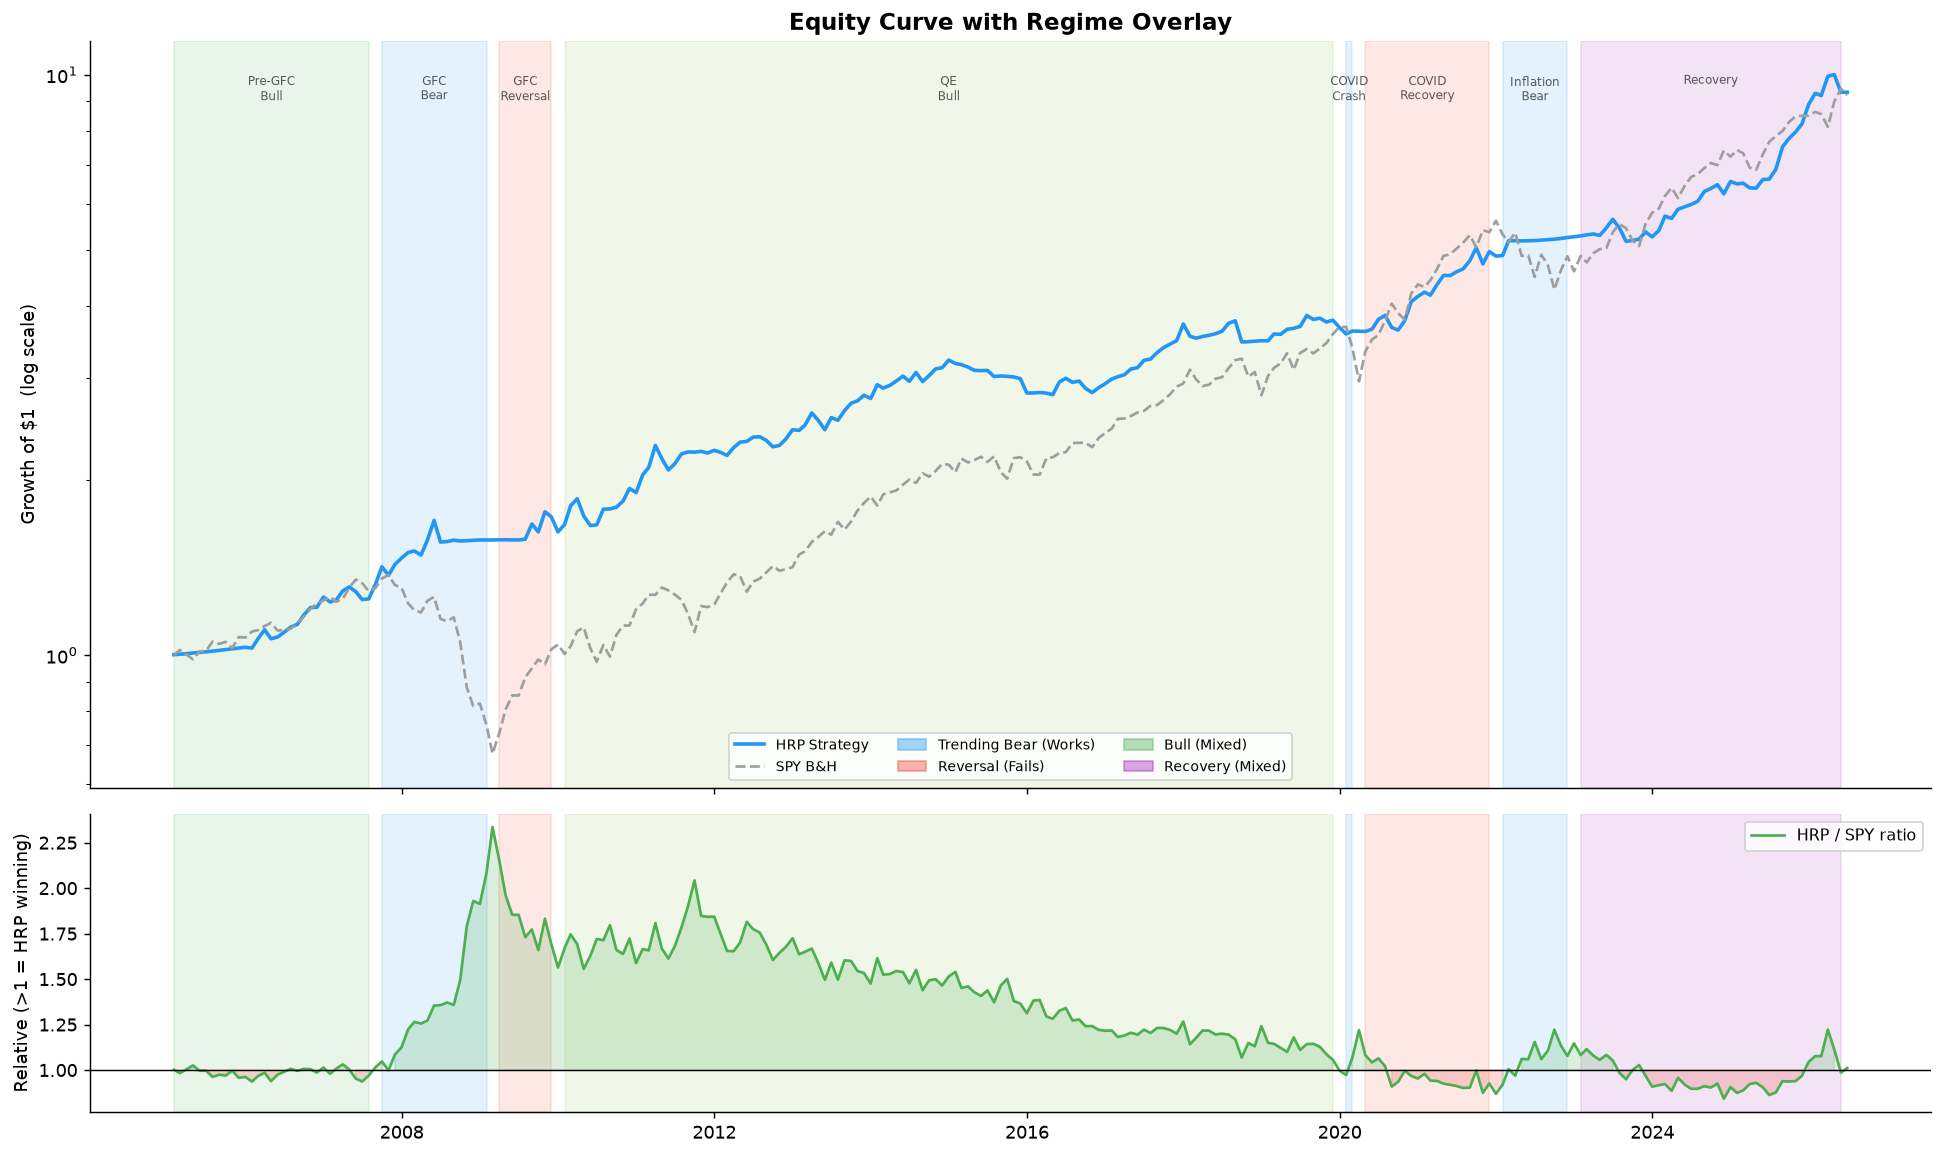

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1]})

hrp_eq = (1 + hrp_ret).cumprod()
spy_eq = (1 + spy_ret.reindex(hrp_ret.index).fillna(0)).cumprod()
rel_eq = hrp_eq / spy_eq   # relative performance

# Shade regimes
for name, (start, end) in REGIMES.items():
    c    = REGIME_COLOR[name]
    mask = (hrp_ret.index >= start) & (hrp_ret.index <= end)
    if mask.any():
        s = hrp_ret.index[mask][0]
        e = hrp_ret.index[mask][-1]
        ax1.axvspan(s, e, alpha=0.12, color=c)
        mid = s + (e - s) / 2
        ax1.text(mid, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 1 else 10,
                 name.replace(' ', '\n'), ha='center', va='top', fontsize=6.5, color='#333', alpha=0.8)
        ax2.axvspan(s, e, alpha=0.12, color=c)

ax1.plot(hrp_eq.index, hrp_eq.values, color='#2196F3', linewidth=2, label='HRP Strategy')
ax1.plot(spy_eq.index, spy_eq.values, color='#9E9E9E', linewidth=1.5, linestyle='--', label='SPY B&H')
ax1.set_yscale('log')
ax1.set_ylabel('Growth of $1  (log scale)')
ax1.set_title('Equity Curve with Regime Overlay', fontweight='bold', fontsize=13)
ax1.legend(fontsize=9)

# Relative performance (HRP / SPY)
ax2.plot(rel_eq.index, rel_eq.values, color='#4CAF50', linewidth=1.5, label='HRP / SPY ratio')
ax2.axhline(1, color='black', linewidth=0.8)
ax2.fill_between(rel_eq.index, rel_eq.values, 1,
                 where=(rel_eq.values > 1), alpha=0.2, color='#4CAF50')
ax2.fill_between(rel_eq.index, rel_eq.values, 1,
                 where=(rel_eq.values <= 1), alpha=0.2, color='#F44336')
ax2.set_ylabel('Relative (>1 = HRP winning)')
ax2.legend(fontsize=9)

# Legend for regime colors
patches = [
    mpatches.Patch(color='#2196F3', alpha=0.4, label='Trending Bear (Works)'),
    mpatches.Patch(color='#F44336', alpha=0.4, label='Reversal (Fails)'),
    mpatches.Patch(color='#4CAF50', alpha=0.4, label='Bull (Mixed)'),
    mpatches.Patch(color='#9C27B0', alpha=0.4, label='Recovery (Mixed)'),
]
ax1.legend(handles=ax1.get_legend_handles_labels()[0] + patches, fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

## Rolling 12-Month Sharpe with Regime Annotation

Shows exactly *when* momentum is working and when it's not.  
Note the Sharpe collapses during the GFC Reversal (2009) and COVID Recovery (2020-2021).

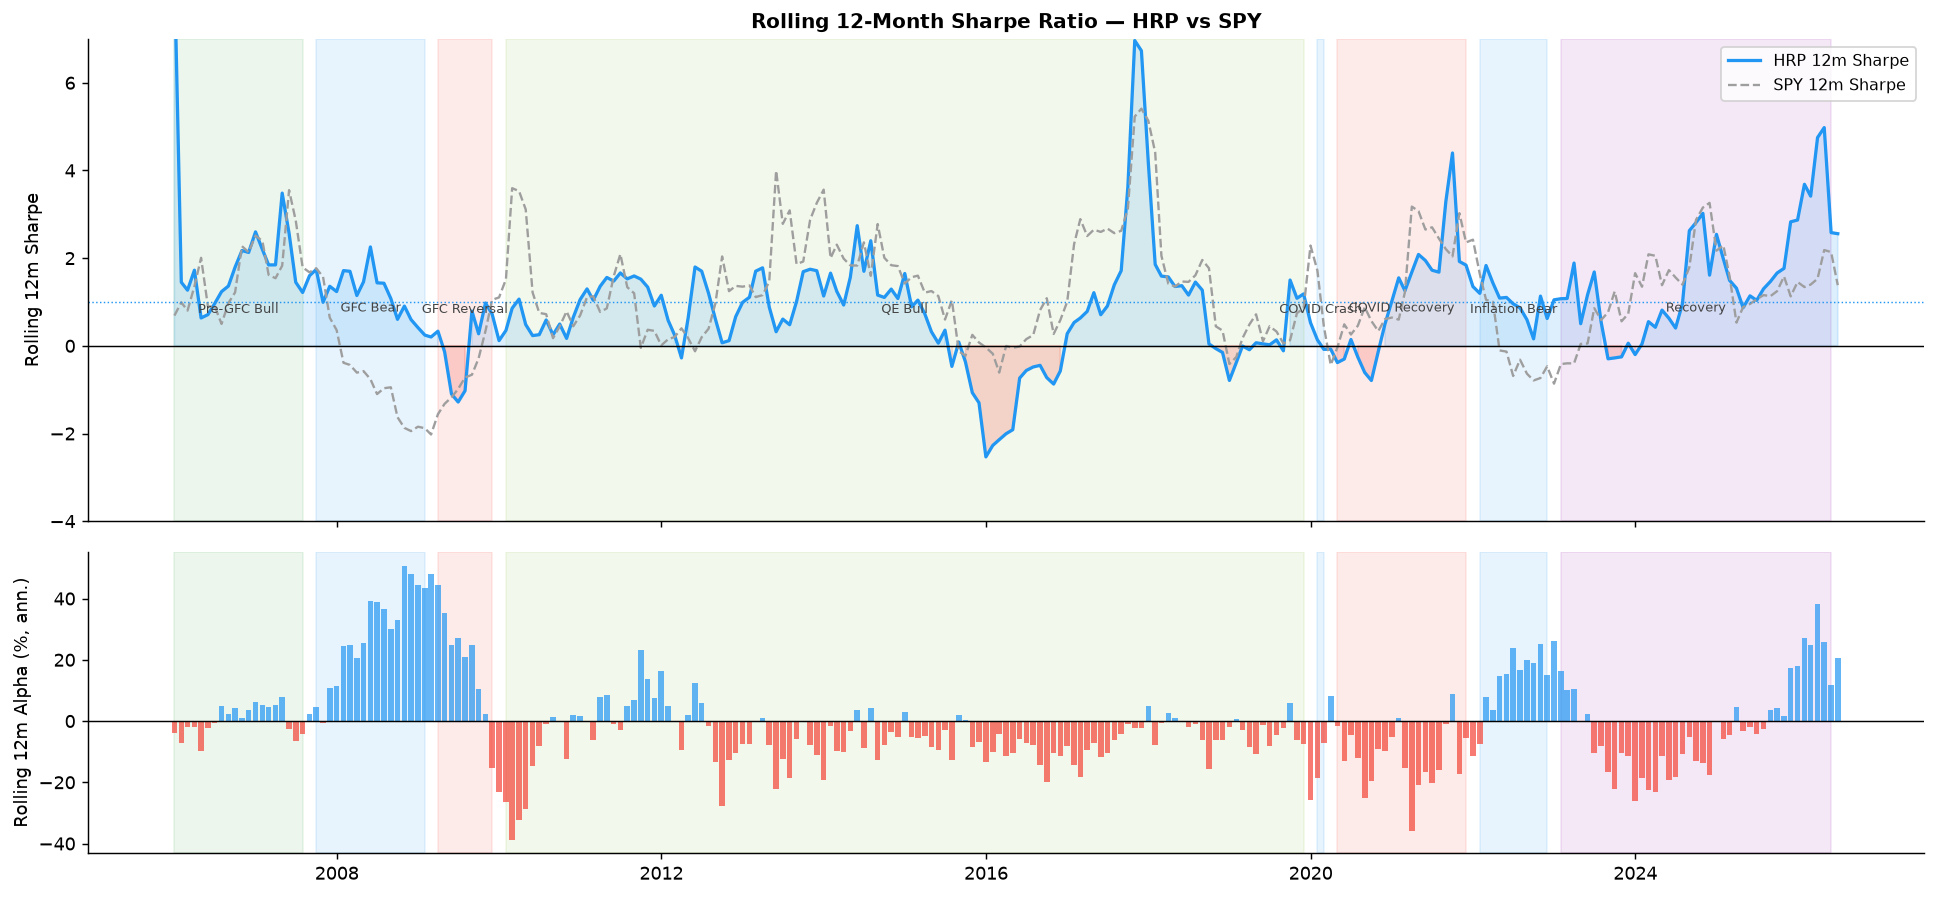

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                                gridspec_kw={'height_ratios': [1.6, 1]})

# Shade regimes on both axes
for name, (start, end) in REGIMES.items():
    c    = REGIME_COLOR[name]
    mask = (roll.index >= start) & (roll.index <= end)
    if mask.any():
        s = roll.index[mask][0]
        e = roll.index[mask][-1]
        ax1.axvspan(s, e, alpha=0.10, color=c)
        ax2.axvspan(s, e, alpha=0.10, color=c)
        ax1.text(s + (e-s)*0.5, ax1.get_ylim()[1] if ax1.get_ylim()[1]>0 else 3,
                 name, ha='center', va='top', fontsize=7, color='#444', rotation=0)

ax1.plot(roll.index, roll['HRP Sharpe'],  color='#2196F3', linewidth=1.8, label='HRP 12m Sharpe')
ax1.plot(roll.index, roll['SPY Sharpe'],  color='#9E9E9E', linewidth=1.3, linestyle='--', label='SPY 12m Sharpe')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axhline(1, color='#2196F3', linewidth=0.8, linestyle=':')
ax1.fill_between(roll.index, roll['HRP Sharpe'], 0,
                 where=(roll['HRP Sharpe'] > 0), alpha=0.15, color='#2196F3')
ax1.fill_between(roll.index, roll['HRP Sharpe'], 0,
                 where=(roll['HRP Sharpe'] <= 0), alpha=0.20, color='#F44336')
ax1.set_ylabel('Rolling 12m Sharpe')
ax1.set_title('Rolling 12-Month Sharpe Ratio — HRP vs SPY', fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(-4, 7)

ax2.bar(roll.index, roll['Active CAGR'], color=[
    '#2196F3' if v >= 0 else '#F44336' for v in roll['Active CAGR']
], alpha=0.7, width=25)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Rolling 12m Alpha (%, ann.)')

plt.tight_layout()
plt.show()

## The Momentum Crash Anatomy

Zoom into the two classic momentum crash episodes:
- **GFC Reversal** (March 2009 – December 2009): SPY +68%, HRP +4% — 64pp underperformance
- **COVID Recovery** (April 2020 – December 2021): SPY +44%, HRP +19% — 25pp underperformance

**Why?** After a sharp bear market, the *worst performers* (recent losers) stage the biggest bounces. Momentum holds the *winners* from the bear market (e.g., bonds, gold) and misses the violent reversal in equities.

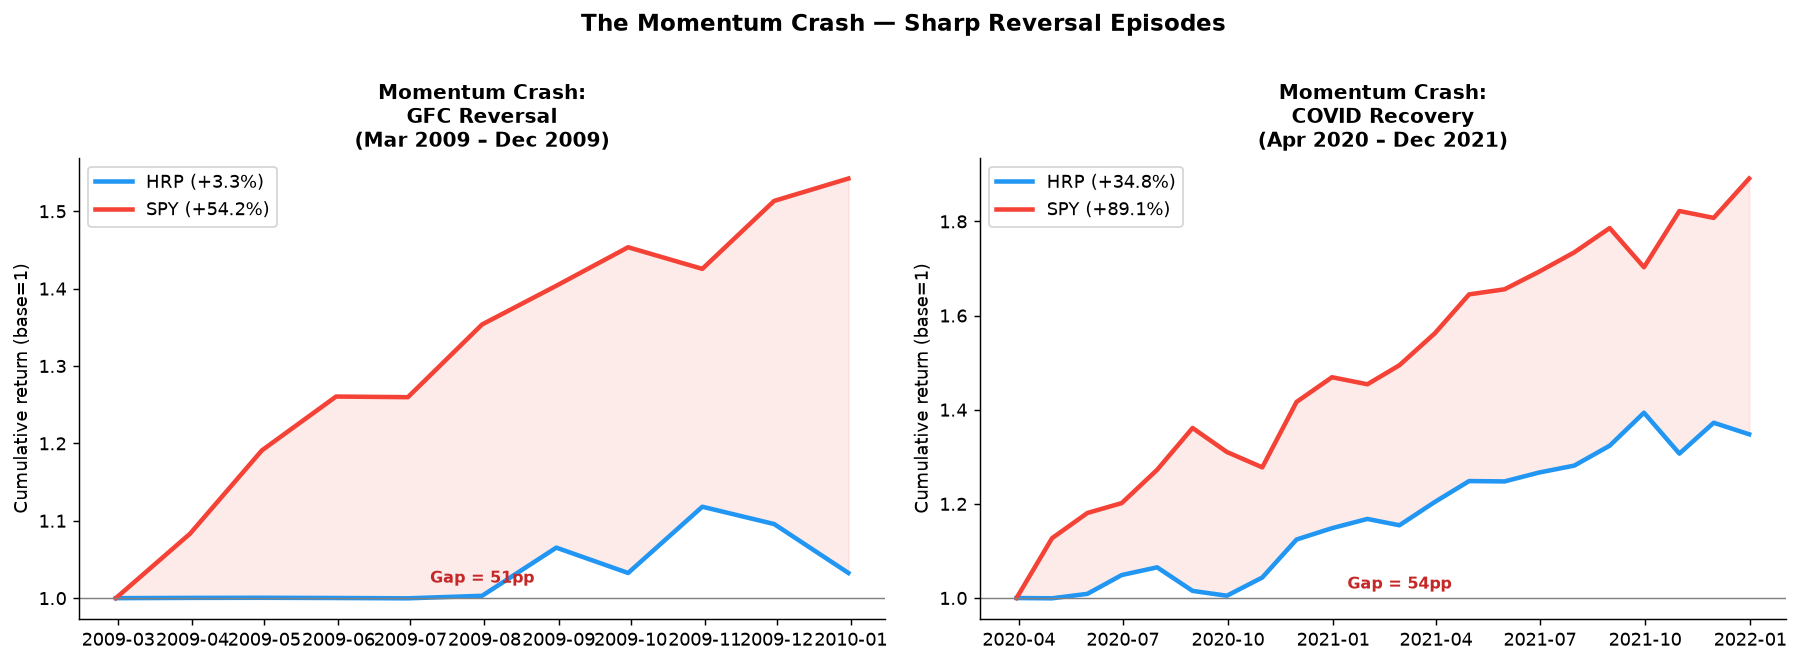

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crash_episodes = [
    ('GFC Reversal\n(Mar 2009 – Dec 2009)', '2009-03', '2009-12', axes[0]),
    ('COVID Recovery\n(Apr 2020 – Dec 2021)', '2020-04', '2021-12', axes[1]),
]

for (title, start, end, ax) in crash_episodes:
    h = hrp_ret.loc[start:end]
    s = spy_ret.reindex(h.index).fillna(0)

    hrp_eq_ep = (1 + h).cumprod()
    spy_eq_ep = (1 + s).cumprod()

    # Prepend 1.0 at start
    base_date = h.index[0] - pd.DateOffset(months=1)
    hrp_eq_ep = pd.concat([pd.Series([1.0], index=[base_date]), hrp_eq_ep])
    spy_eq_ep = pd.concat([pd.Series([1.0], index=[base_date]), spy_eq_ep])

    ax.plot(hrp_eq_ep.index, hrp_eq_ep.values, color='#2196F3', linewidth=2.5, label=f'HRP ({hrp_eq_ep.iloc[-1]-1:+.1%})')
    ax.plot(spy_eq_ep.index, spy_eq_ep.values, color='#F44336',  linewidth=2.5, label=f'SPY ({spy_eq_ep.iloc[-1]-1:+.1%})')
    ax.fill_between(spy_eq_ep.index, hrp_eq_ep.values, spy_eq_ep.values, alpha=0.10, color='#F44336')
    ax.axhline(1, color='gray', linewidth=0.8)
    ax.set_title(f'Momentum Crash:\n{title}', fontweight='bold')
    ax.set_ylabel('Cumulative return (base=1)')
    ax.legend(fontsize=10)

    gap = (spy_eq_ep.iloc[-1] - hrp_eq_ep.iloc[-1]) * 100
    ax.text(hrp_eq_ep.index[len(hrp_eq_ep)//2], 1.02,
            f'Gap = {gap:.0f}pp', ha='center', fontsize=9, color='#C62828', fontweight='bold')

fig.suptitle('The Momentum Crash — Sharp Reversal Episodes', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Monthly Return Scatter: What market environment hurts momentum?

Each point is a month. X-axis = SPY return. Y-axis = HRP excess return vs SPY.  

**Pattern**: Momentum WINS in big down months (protection). Momentum LAGS in big up months after a crash (misses the reversal).

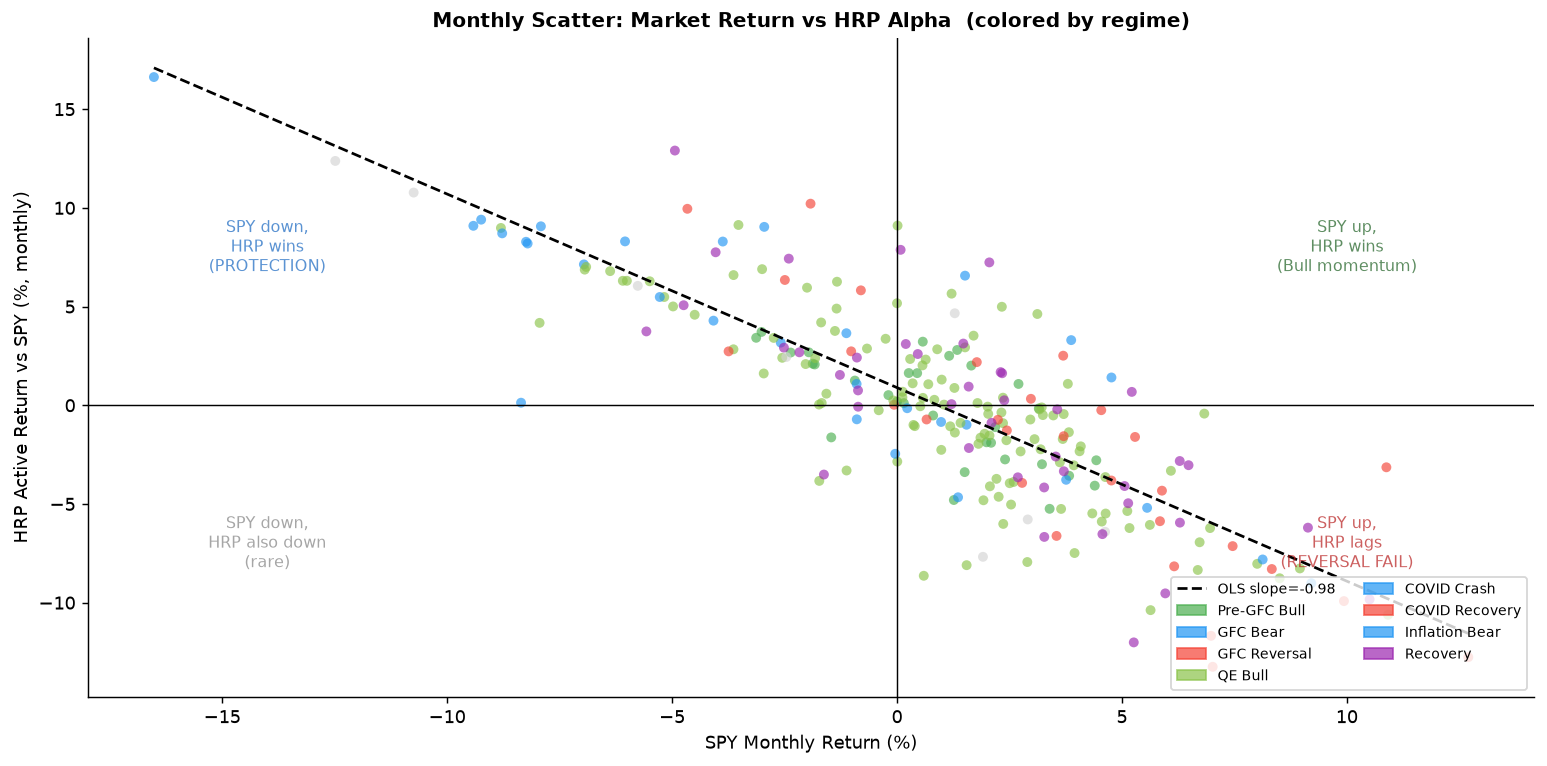

OLS slope (beta of alpha vs SPY return): -0.981
Correlation (SPY return vs HRP alpha): r=-0.821, p=0.0000
-> Negative slope = momentum protects in crashes, lags in sharp rallies.


In [8]:
spy_aligned = spy_ret.reindex(hrp_ret.index).fillna(0)
active_mo   = (hrp_ret - spy_aligned) * 100
spy_mo_pct  = spy_aligned * 100

# Assign regime color to each month
month_colors = pd.Series('lightgray', index=hrp_ret.index)
for name, (start, end) in REGIMES.items():
    mask = (hrp_ret.index >= start) & (hrp_ret.index <= end)
    month_colors[mask] = REGIME_COLOR[name]

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(spy_mo_pct.values, active_mo.values,
           c=month_colors.values, alpha=0.65, s=30, edgecolors='none')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

# Regression line
mask_valid = ~(np.isnan(spy_mo_pct) | np.isnan(active_mo))
x_v = spy_mo_pct.values[mask_valid]
y_v = active_mo.values[mask_valid]
m, b = np.polyfit(x_v, y_v, 1)
x_line = np.linspace(x_v.min(), x_v.max(), 100)
ax.plot(x_line, m*x_line + b, color='black', linewidth=1.5, linestyle='--',
        label=f'Trend: slope={m:.2f}')

# Quadrant labels
ax.text(-14, 8, 'SPY down,\nHRP wins\n(PROTECTION)', ha='center', va='center',
        fontsize=9, color='#1565C0', alpha=0.7)
ax.text(10, 8, 'SPY up,\nHRP wins\n(Bull momentum)', ha='center', va='center',
        fontsize=9, color='#1B5E20', alpha=0.7)
ax.text(-14, -7, 'SPY down,\nHRP also down\n(rare)', ha='center', va='center',
        fontsize=9, color='gray', alpha=0.7)
ax.text(10, -7, 'SPY up,\nHRP lags\n(REVERSAL FAIL)', ha='center', va='center',
        fontsize=9, color='#B71C1C', alpha=0.7)

# Legend for regime colors
patches = [mpatches.Patch(color=REGIME_COLOR[r], label=r, alpha=0.7) for r in REGIMES]
ax.legend(handles=patches, fontsize=8, ncol=2, loc='lower right')
ax.legend([plt.Line2D([0],[0],color='k',linestyle='--')] + patches,
          [f'OLS slope={m:.2f}'] + list(REGIMES.keys()),
          fontsize=8, ncol=2, loc='lower right')

ax.set_xlabel('SPY Monthly Return (%)')
ax.set_ylabel('HRP Active Return vs SPY (%, monthly)')
ax.set_title('Monthly Scatter: Market Return vs HRP Alpha  (colored by regime)', fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation and beta
from scipy.stats import pearsonr
r, p = pearsonr(x_v, y_v)
print(f'OLS slope (beta of alpha vs SPY return): {m:.3f}')
print(f'Correlation (SPY return vs HRP alpha): r={r:.3f}, p={p:.4f}')
print('-> Negative slope = momentum protects in crashes, lags in sharp rallies.')

## Regime Summary Table

In [9]:
summary_cols = ['N months', 'HRP CAGR %', 'HRP Sharpe', 'HRP MaxDD %', 'SPY CAGR %', 'Alpha CAGR', 'Sharpe Diff']
display_df = df[summary_cols].copy()

print(f"{'':21} {'N':>3}  {'HRP CAGR':>9}  {'Sharpe':>7}  {'MaxDD':>7}  {'SPY CAGR':>9}  {'Alpha':>8}  {'ΔSharpe':>8}  Verdict")
print("─"*100)
for regime, row in display_df.iterrows():
    verdict = '★ WINS' if row['Alpha CAGR'] > 0 else '✗ FAILS'
    print(f"{regime:21} {int(row['N months']):>3}  {row['HRP CAGR %']:>8.2f}%  "
          f"{row['HRP Sharpe']:>7.3f}  {row['HRP MaxDD %']:>6.2f}%  "
          f"{row['SPY CAGR %']:>8.2f}%  {row['Alpha CAGR']:>+7.2f}%  "
          f"{row['Sharpe Diff']:>+8.3f}  {verdict}")

print("─"*100)
wins  = (df['Alpha CAGR'] > 0).sum()
total = len(df)
print(f"\nConclusion: Momentum wins in {wins}/{total} regimes.")
print("  WORKS in: trending markets (bull OR bear) — clear leaders, sustained trends.")
print("  FAILS in: sharp reversals — recent losers suddenly become winners overnight.")
print("  LAGS in : low-vol grind bull markets — everything rises, no rotation signal.")

                        N   HRP CAGR   Sharpe    MaxDD   SPY CAGR     Alpha   ΔSharpe  Verdict
────────────────────────────────────────────────────────────────────────────────────────────────────
Pre-GFC Bull           32     11.13%    0.972   -4.89%     10.87%    +0.26%    +0.075  ★ WINS
GFC Bear               18     12.45%    0.814   -8.23%    -35.49%   +47.94%    +2.687  ★ WINS
GFC Reversal           10      3.92%    0.266   -7.65%     68.19%   -64.27%    -4.946  ✗ FAILS
QE Bull               120      8.44%    0.813  -12.86%     13.44%    -5.00%    -0.223  ✗ FAILS
COVID Crash             3     -5.81%   -1.067   -0.11%    -57.90%   +52.09%    +1.635  ★ WINS
COVID Recovery         21     18.60%    1.609   -6.23%     43.92%   -25.32%    -1.285  ✗ FAILS
Inflation Bear         12      7.97%    1.006   -0.08%    -18.18%   +26.15%    +1.881  ★ WINS
Recovery               42     17.80%    1.165   -8.36%     22.12%    -4.32%    -0.194  ✗ FAILS
────────────────────────────────────────────────